In [18]:
%matplotlib widget

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.widgets import CheckButtons

In [2]:
native = gpd.read_file("data/different_cois/Native_Areas.geojson")
parks_y_rec= gpd.read_file("data/different_cois/Parks_and_Rec_Districts.geojson")
superclean = gpd.read_file('data/different_cois/superclean_co_comm.geojson')
oil_y_gas = gpd.read_file('data/different_cois/districtr_oilgas_shape.shp/tmp/export-7880.shp')
libraries = gpd.read_file('data/different_cois/Library_Districts/DOLA_Districts.shp')
fed_lands = gpd.read_file('data/different_cois/USA_Federal_Lands/USA_Federal_Lands.shp')
dis_imp_comm = gpd.read_file('data/different_cois/Dispro_Impact_Comms_filtered.shp')
ski_areas = gpd.read_file('data/different_cois/ski_areas/tmp/export-8331.shp') 
co_border = gpd.read_file('data/different_cois/Colorado_State_Boundary/Colorado_State_Boundary.shp') 

'''
print(len(native))
print(len(parks_y_rec))
print(len(superclean))
print(len(oil_y_gas)) #12
print(len(libraries))
print(len(fed_lands))
print(len(dis_imp_comm))
print(len(ski_areas))
'''

group_oil_y_gas = oil_y_gas.dissolve(by="community", aggfunc="sum") # might want to change aggfunc parameter if we want to use some of the columns appropriately
group_ski_areas = ski_areas.dissolve(by="community", aggfunc="sum") # might want to change aggfunc parameter if we want to use some of the columns appropriately


print(group_ski_areas['TOTPOP'])


if libraries.crs != superclean.crs:
    libraries = libraries.to_crs(superclean.crs)

if fed_lands.crs != superclean.crs:
    fed_lands = fed_lands.to_crs(superclean.crs)




community
Community 1    12809
Community 2     9750
Community 3    10555
Community 4    13510
Community 5    43232
Name: TOTPOP, dtype: int64


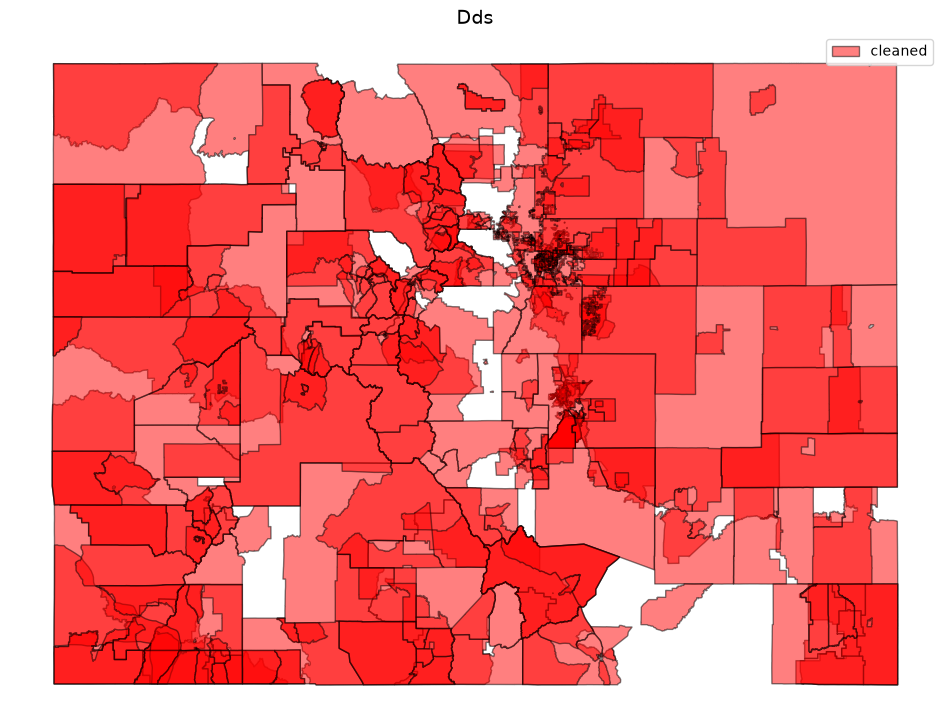

                                              geometry  \
0    POLYGON ((-105.21338 38.4215, -105.21338 38.42...   
1    POLYGON ((-105.16074 39.60835, -105.16065 39.6...   
2    POLYGON ((-102.85019 37.08898, -102.85002 37.0...   
3    POLYGON ((-105.91575 40.4017, -105.91662 40.40...   
4    MULTIPOLYGON (((-109.0454 37.2122, -109.04535 ...   
..                                                 ...   
585  POLYGON ((-104.87061 39.86265, -104.8706 39.86...   
586  POLYGON ((-104.84369 39.81679, -104.84418 39.8...   
587  POLYGON ((-104.83247 39.86909, -104.83348 39.8...   
588  POLYGON ((-104.8468 39.87006, -104.8468 39.868...   
589  POLYGON ((-104.84816 39.88821, -104.85204 39.8...   

                                             STATEFP20  \
0               08080808080808080808080808080808080808   
1    0808080808080808080808080808080808080808080808...   
2                             080808080808080808080808   
3                                           0808080808   
4    08080808

In [4]:
native = native.to_crs(superclean.crs)
group_ski_areas = ski_areas.to_crs(superclean.crs)
dis_imp_comm = dis_imp_comm.to_crs(superclean.crs)
parks_y_rec = parks_y_rec.to_crs(superclean.crs)
libraries = libraries.to_crs(superclean.crs)
#superclean = superclean.to_crs(superclean.crs)
fed_lands = fed_lands.to_crs(superclean.crs)
group_oil_y_gas = group_oil_y_gas.to_crs(superclean.crs)

# 2. Add a category column to keep track of feature types
native["category"] = "native"
dis_imp_comm["category"] = "disproportionately_impacted_community"
parks_y_rec["category"] = "parks and rec"
libraries["category"] = "libraries"
group_oil_y_gas["category"] = "oil and gas"
superclean["category"] = "cleaned representable"
fed_lands["category"] = "federal lands"
group_ski_areas['category'] = "ski areas"

cols = ["category", "geometry"]
# 3. Concatenate into a single GeoDataFrame
all_maps = gpd.GeoDataFrame(
    pd.concat([ group_oil_y_gas, superclean, native, libraries, parks_y_rec, group_ski_areas, dis_imp_comm, fed_lands], ignore_index=True),
    crs=superclean.crs
)

fig, ax = plt.subplots(figsize=(12, 10))

all_maps.plot(ax=ax, color = "red", alpha=0.5, edgecolor="black", label = "cleaned")

ax.set_title("Dds", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()

print(all_maps)

# 4. Save to GeoJSON or Shapefile
# Export as GeoJSON:
all_maps.to_file("data/different_cois/all_maps.geojson", driver="GeoJSON")


In [4]:
native.to_file('data/different_cois/native.geojson', driver='GeoJSON')
parks_y_rec.to_file('data/different_cois/parks_and_rec.geojson', driver='GeoJSON')
superclean.to_file('data/different_cois/cleaned_representable.geojson', driver='GeoJSON')
group_oil_y_gas.to_file('data/different_cois/oil_and_gas.geojson', driver='GeoJSON')
group_ski_areas.to_file('data/different_cois/ski_areas.geojson', driver='GeoJSON')
libraries.to_file('data/different_cois/libraries.geojson', driver='GeoJSON')
fed_lands.to_file('data/different_cois/d_o_d.geojson', driver='GeoJSON')
dis_imp_comm.to_file('data/different_cois/disprop_comms.geojson', driver='GeoJSON')


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

superclean.plot(ax=ax, color = "red", alpha=0.5, edgecolor="black", label = "cleaned")
parks_y_rec.plot(ax=ax, color = "green", alpha=0.5, edgecolor="black", label = "park and rec")
native.plot(ax=ax, color = "orange", alpha=0.5, edgecolor="black", label = "native")
oil_y_gas.plot(ax=ax, color = "black", alpha=0.5, edgecolor="black", label = "oil and gas")
libraries.plot(ax=ax, color = "yellow", alpha=0.5, edgecolor="black", label = "libraries")
fed_lands.plot(ax=ax, color = "blue", alpha=0.5, edgecolor="black", label = "federal lands")
dis_imp_comm.plot(ax=ax, color = "pink", alpha=0.5, edgecolor="black", label = "impacted comms")
ski_areas.plot(ax=ax, color = "purple", alpha=0.5, edgecolor="black", label = "purple")

ax.set_title("Dds", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()


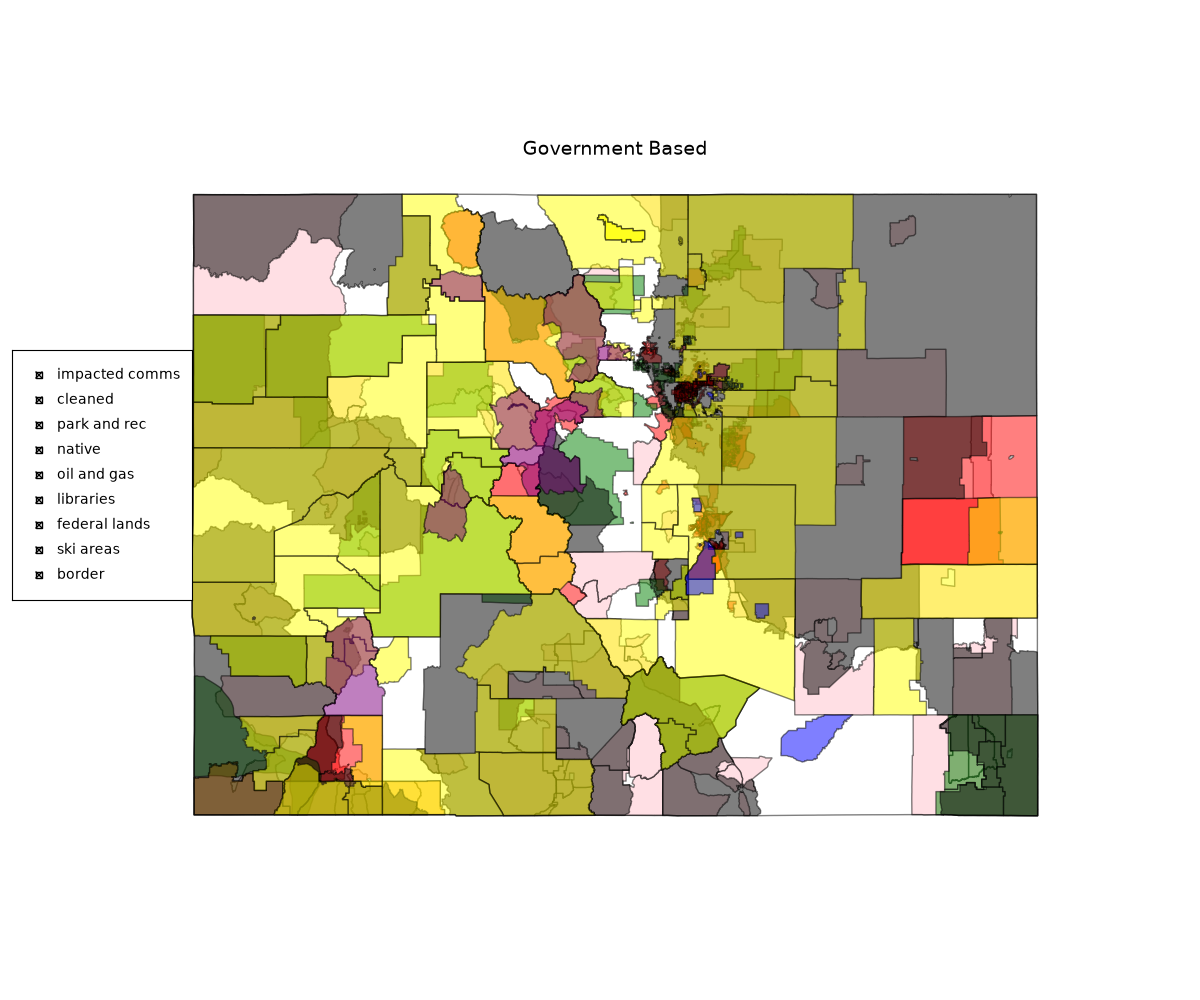

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

layers = []
labels = []

def add_layer(gdf, label, color):
    # Plot and grab the LAST collection added
    gdf.plot(ax=ax, color=color, alpha=0.5, edgecolor="black", label=label)
    coll = ax.collections[-1]  # last added collection
    layers.append(coll)
    labels.append(label)

# Add all layers
add_layer(dis_imp_comm, 'impacted comms', 'pink')
add_layer(superclean, "cleaned", "red")
add_layer(parks_y_rec, "park and rec", "green")
add_layer(native, "native", "orange")
add_layer(group_oil_y_gas, "oil and gas", "black")
add_layer(libraries, "libraries", "yellow")
add_layer(fed_lands, "federal lands", "blue")
add_layer(group_ski_areas, "ski areas", "purple")
add_layer(co_border, "border", "none")

ax.set_title("Government Based", fontsize=14)
ax.axis("off")

# Create CheckButtons
rax = plt.axes([0.01, 0.4, 0.15, 0.25])
check = CheckButtons(rax, labels, [True] * len(labels))

def toggle(label):
    idx = labels.index(label)
    layers[idx].set_visible(not layers[idx].get_visible())
    plt.draw()

check.on_clicked(toggle)

plt.show()